In [1]:
import pandas as pd
import os
import time
import re
from pathlib import Path
import pandasai as pai
from pandasai_litellm.litellm import LiteLLM
from litellm import completion

In [2]:
df_clinic_level = pd.read_csv("cc_clinic_level.csv")
df_doctor = pd.read_csv("cc_doctor.csv")
df_hourly = pd.read_csv("cc_hourly.csv")
df_patient = pd.read_csv("cc_patient.csv")

df_clinic_level = pai.DataFrame(df_clinic_level)
df_doctor = pai.DataFrame(df_doctor)
df_hourly = pai.DataFrame(df_hourly)
df_patient = pai.DataFrame(df_patient)

In [4]:
def generate_Response(question: str, dataframes: list, model_id: str = None, api_key: str = None):
    """
    Generate a response using PandasAI for the given question.
    
    Args:
        question: The question to ask
        dataframes: List of PandasAI DataFrames to query
        model_id: The LLM model identifier
        api_key: API key for the LLM
    
    Returns:
        tuple: (response, elapsed_time)
    """
    default_api_key = "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"
    default_model = "nvidia_nim/mistralai/mistral-large-3-675b-instruct-2512"
    
    # Configure the LLM
    llm = LiteLLM(
        model=model_id or default_model,
        api_key=api_key or default_api_key,
        stream=False,
    )
    pai.config.set({"llm": llm, "save_charts": False})
    
    start_time = time.time()
    response = pai.chat(question, *dataframes)
    elapsed_time = time.time() - start_time
    
    return response, elapsed_time

In [5]:
def extract_Generated_code(log_path: str = "pandasai.log"):
    """
    Extract the full generated code from PandasAI log.
    
    Returns:
        dict: {"sql_query": str, "full_code": str}
    """
    from pathlib import Path
    
    log_file = Path(log_path)
    if not log_file.exists():
        return {"sql_query": "", "full_code": ""}
    
    text = log_file.read_text(encoding="utf-8")
    
    # --- Extract full generated code from "Executing code:" section ---
    full_code = ""
    # Pattern to find code after "Executing code:" until next log entry or end
    exec_pattern = r'\[INFO\] Executing code:\s*(.+?)(?=\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2} \[INFO\]|$)'
    exec_matches = re.findall(exec_pattern, text, re.DOTALL)
    if exec_matches:
        full_code = exec_matches[-1].strip()
    
    # --- Extract SQL query from the full code ---
    sql_query = ""
    # Pattern for triple-quoted multi-line SQL
    multi_line_pattern = r'sql_query\s*=\s*"""(.+?)"""'
    single_quote_pattern = r"sql_query\s*=\s*'([^']+)'"
    double_quote_pattern = r'sql_query\s*=\s*"([^"]+)"'

    # Search in full_code first, then in entire text
    search_text = full_code if full_code else text
    
    matches = re.findall(multi_line_pattern, search_text, re.DOTALL)
    if not matches:
        matches = re.findall(single_quote_pattern, search_text)
    if not matches:
        matches = re.findall(double_quote_pattern, search_text)
    if matches:
        sql_query = matches[-1].strip()
    
    return {"sql_query": sql_query, "full_code": full_code}


def clear_log(log_path: str = "pandasai.log"):
    """Clear the PandasAI log file after extraction."""
    from pathlib import Path
    log_file = Path(log_path)
    if log_file.exists():
        log_file.write_text("", encoding="utf-8")

In [6]:
def validation_Response(query: str, question: str,response=None,answer=None) -> bool:
    if not query:
        return False
    
    try:
        validation = completion(
            model="nvidia_nim/meta/llama-3.1-405b-instruct",
            messages=[{
                "role": "user", 
                "content": f"""You are a query validator.
                Question: {question}
                Code: {query}
                response: {response} if response is chart or visualization, compare answer with the query else compare response with the answer
                answer: {answer}
                Does this code correctly retrieve the data required to answer the question?
                Respond with ONLY one word: TRUE or FALSE."""
            }],
            api_key= "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"
            
        )
        return validation.choices[0].message.content.strip()
        
    except Exception as e:
        print(f"⚠️ Validation error: {e}")
        return None

In [7]:
def error_explaination_Response(query: str, question: str, response=None, answer=None) -> str:
    if not query:
        return "No code generated to validate."
    
    try:
        explanation = completion(
            model="nvidia_nim/meta/llama-3.1-405b-instruct",
            messages=[{
                "role": "user", 
                "content": f"""You are a helpful assistant that explains errors in code.
                Question: {question}
                Code: {query}
                Response: {response}
                Answer: {answer}
                the code is determine by the llms judge passed to you thats means it is wrong, explain what is wrong with it and how to fix it. If the code is correct, say "The code is correct."."""
            }],
            api_key= "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"
        )
        return explanation.choices[0].message.content.strip()
        
    except Exception as e:
        print(f"⚠️ Explanation error: {e}")
        return "An error occurred while generating the explanation."

In [19]:
clear_log()
# Simple test using the helper functions
question = "Which clinic serves the highest number of patients from different countries, and which doctor handles the majority of those patients?"

# Use generate_Response function
response, elapsed_time = generate_Response(question, [df_doctor, df_hourly, df_patient,df_clinic_level])
print(f"Response: {response.value if hasattr(response, 'value') else response}")

# Extract full generated code
generated = extract_Generated_code()
print(f"\nSQL Query:\n{generated['sql_query']}")
print(f"\nFull Code:\n{generated['full_code']}")

# Use validation_Response function with full_code for complete validation
code_to_validate = generated['full_code'] if generated['full_code'] else generated['sql_query']
is_correct = validation_Response(code_to_validate, question, response=response, answer=""""DOCTOR HE treats 1,996 patients at CLINIC T.""")
print(f"\nIs Correct: {is_correct}")

# Check if validation returned "FALSE" (string comparison, case-insensitive)
if is_correct and "false" in str(is_correct).lower():
    explanation = error_explaination_Response(code_to_validate, question, response,answer)
    print(f"\nError Explanation:\n{explanation}")

print(f"Time taken: {elapsed_time:.2f} seconds")

Response: Clinic 'Clinic T' at 99, King Street, George Town, 10200 George Town, Pulau Pinang, Malaysia serves patients from the highest number of countries (27). Doctor Doctor HA handles 38.83% of the patients at this clinic.

SQL Query:


Full Code:
import pandas as pd
query_clinic_countries = """
    SELECT
        t1.IDOrganisation,
        t1.Address,
        COUNT(DISTINCT t3."Countries/Geography") as distinct_countries_count,
        t1."%TotalPatient" as total_patient_percentage
    FROM
        table_c83679f393c19ab82f71054c6c3facb6 t1
    JOIN
        table_3586b23a0be349f88985d8c0d783b36d t3
    ON
        t1.IDOrganisation = t3.IDOrganisation
        AND t1.Address = t3.Address
    GROUP BY
        t1.IDOrganisation,
        t1.Address,
        t1."%TotalPatient"
    ORDER BY
        distinct_countries_count DESC,
        total_patient_percentage DESC
    LIMIT 1
"""
clinic_with_most_countries = execute_sql_query(query_clinic_countries)
query_doctor_patients = """
    SELECT

In [18]:
clear_log()
# Simple test using the helper functions
question = "Create a bar chart of patient religions for the top 3 clinics by total revenue. Analyze religious demographics within high performing clinics."

# Use generate_Response function
response, elapsed_time = generate_Response(question, [df_doctor, df_hourly, df_patient,df_clinic_level])
print(f"Response: {response.value if hasattr(response, 'value') else response}")

# Extract full generated code
generated = extract_Generated_code()
print(f"\nSQL Query:\n{generated['sql_query']}")
print(f"\nFull Code:\n{generated['full_code']}")

# Use validation_Response function with full_code for complete validation
code_to_validate = generated['full_code'] if generated['full_code'] else generated['sql_query']
is_correct = validation_Response(code_to_validate, question, response=response)
print(f"\nIs Correct: {is_correct}")

# Check if validation returned "FALSE" (string comparison, case-insensitive)
if is_correct and "false" in str(is_correct).lower():
    explanation = error_explaination_Response(code_to_validate, question, response)
    print(f"\nError Explanation:\n{explanation}")

print(f"Time taken: {elapsed_time:.2f} seconds")

Response: exports\charts\temp_chart_f09616b6-af2f-41b1-bbfd-d7428117261c.png

SQL Query:


Full Code:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
top_clinics_query = """
SELECT
    t1.IDOrganisation,
    t1.Address,
    t1.TotalRevenue,
    t4.Religions,
    COUNT(*) as ReligionCount
FROM
    table_bd4f8d5ffa8239c09831e5b997bc2753 t1
JOIN
    table_3586b23a0be349f88985d8c0d783b36d t4
    ON t1.IDOrganisation = t4.IDOrganisation
WHERE
    t1.IDOrganisation IN (
        SELECT IDOrganisation
        FROM table_bd4f8d5ffa8239c09831e5b997bc2753
        ORDER BY TotalRevenue DESC
        LIMIT 3
    )
GROUP BY
    t1.IDOrganisation, t1.Address, t1.TotalRevenue, t4.Religions
ORDER BY
    t1.TotalRevenue DESC, ReligionCount DESC
"""
top_clinics_religion = execute_sql_query(top_clinics_query)
plt.figure(figsize=(12, 6))
sns.barplot(data=top_clinics_religion, x='IDOrganisation', y='ReligionCount', hue='Religions')
plt.title('Patient Religions in Top 3 Clinics by To

In [21]:
# Benchmark Test Questions with Expected Answers
# Each entry: {"question": str, "answer": str, "dataframes": list}

benchmark_questions = {
    "easy": [
        {
            "question": "Which clinic has the highest TotalRevenue?",
            "answer": "Clinic I",
            "dataframes": [df_clinic_level]
        },
        {
            "question": "What is the average TotalRevenue across all clinics?",
            "answer": "1,220,906.65",
            "dataframes": [df_clinic_level]
        },
        {
            "question": "List all unique Districts present in the dataset.",
            "answer": "Bandar Enstek, Bangi, Batang Kali, Batu Caves, Bayan Lepas, Central KL, Cheras, Desa Pandan, Dungun, Georgetown, Hulu Langat, Ipoh, Kajang, Kota Bharu, Kuala Langat, Kuala Lumpur, Kuantan, Kulim, Mantin, Muar, Pasir Mas, Petaling, Petaling Jaya, Presint 8, Rawang, Semenyih, Sepang, Seremban, Setia Alam, Shah Alam, Skudai, Wakaf Bharu",
            "dataframes": [df_clinic_level]
        },
        {
            "question": "Which hour has the highest patient count?",
            "answer": "2025-10-13 20:00:00",
            "dataframes": [df_hourly]
        },
        {
            "question": "Which state generates the highest total revenue?",
            "answer": "Selangor",
            "dataframes": [df_clinic_level]
        }
    ],
    "medium": [
        {
            "question": "Which doctor treats the highest number of patients from Malay ethnicity?",
            "answer": "Doctor B",
            "dataframes": [df_doctor, df_patient]
        },
        {
            "question": "Which doctor sees the most patients from Married social status group?",
            "answer": "Doctor BZ",
            "dataframes": [df_doctor, df_patient]
        },
        {
            "question": "Which doctor has the highest number of patients from different country/geography?",
            "answer": "Doctor AW treats the most patients from Australia, Bangladesh, Canada, Germany, India, Japan, Malaysia, Philippines, and Singapore",
            "dataframes": [df_doctor, df_patient]
        },
        {
            "question": "Which clinic has the highest revenue and how many doctors work there?",
            "answer": "Clinic I with 15 doctors",
            "dataframes": [df_clinic_level, df_doctor]
        },
        {
            "question": "Which doctor treats the highest number of patients from Malay ethnicity in the highest revenue clinic?",
            "answer": "Doctor B in Clinic I",
            "dataframes": [df_clinic_level, df_doctor, df_patient]
        }
    ],
    "hard": [
        {
            "question": "Create a bar chart of patient religions for the top 3 clinics by total revenue. Analyze religious demographics within high performing clinics.",
            "answer": "Bar chart showing religious distribution",
            "dataframes": [df_clinic_level, df_patient]
        },
        {
            "question": "Plot the relationship between a clinic's total revenue and the number of doctors it employs.",
            "answer": "Scatter plot of revenue vs doctor count",
            "dataframes": [df_clinic_level, df_doctor]
        },
        {
            "question": "Top 5 doctors with the highest patient counts.",
            "answer": "Bar chart of top 5 doctors by patient count",
            "dataframes": [df_doctor]
        },
        {
            "question": "Create a stacked bar chart of show top 5 patient religion counts by state. Visualize Top 3 religious demographics in regions.",
            "answer": "Stacked bar chart of religions by state",
            "dataframes": [df_clinic_level, df_patient]
        },
        {
            "question": "Plot the  the top 5 high patient count doctors working in clinics with the highest revenue.",
            "answer": "Combined chart of top clinics and doctors",
            "dataframes": [df_clinic_level, df_doctor]
        }
    ]
}

# Models to test
models_to_test = [
    ("nvidia_nim/meta/llama-3.1-8b-instruct", "Llama-3.1-8B"),
    ("nvidia_nim/google/gemma-2-27b-it", "Gemma-2-27B"),
    ("nvidia_nim/meta/llama3-70b-instruct", "Llama3-70B"),
    ("nvidia_nim/meta/llama-3.1-405b-instruct", "Llama-3.1-405B"),
    ("nvidia_nim/mistralai/mistral-large-3-675b-instruct-2512", "Mistral-Large-3-675B")
]

print(f"📋 Benchmark configured:")
print(f"   Easy questions: {len(benchmark_questions['easy'])}")
print(f"   Medium questions: {len(benchmark_questions['medium'])}")
print(f"   Hard questions: {len(benchmark_questions['hard'])}")
print(f"   Models to test: {len(models_to_test)}")

📋 Benchmark configured:
   Easy questions: 5
   Medium questions: 5
   Hard questions: 5
   Models to test: 5


In [9]:
# Benchmark Runner - EASY & MEDIUM ONLY
NUM_RUNS = 3
MAX_RETRIES = 1
RESULTS_FILE = "exports/benchmark_results_easy_medium.csv"

os.makedirs("exports", exist_ok=True)

# Load existing results if available
if os.path.exists(RESULTS_FILE) and os.path.getsize(RESULTS_FILE) > 0:
    try:
        results_df = pd.read_csv(RESULTS_FILE)
        results = results_df.to_dict('records')
        print(f"📂 Loaded {len(results)} existing results")
    except pd.errors.EmptyDataError:
        results = []
else:
    results = []
    print("📂 Starting fresh benchmark")


def get_completed_tests(results):
    return {(r['model'], r['difficulty'], r['question'], r.get('run_num', 1)) for r in results}


def save_results(results, filepath):
    pd.DataFrame(results).to_csv(filepath, index=False)


def run_single_test(model_id, model_name, question_data, difficulty, run_num):
    question = question_data["question"]
    expected_answer = question_data["answer"]
    dataframes = question_data["dataframes"]
    
    for attempt in range(MAX_RETRIES + 1):
        try:
            clear_log()
            response, elapsed_time = generate_Response(question, dataframes, model_id=model_id)
            response_value = response.value if hasattr(response, 'value') else str(response)
            
            generated = extract_Generated_code()
            sql_query = generated["sql_query"]
            full_code = generated["full_code"]
            
            code_to_validate = full_code if full_code else sql_query
            is_correct = None
            if code_to_validate:
                is_correct = validation_Response(code_to_validate, question, response=response_value, answer=expected_answer)
            
            return {
                "model": model_name, "difficulty": difficulty, "question": question,
                "expected_answer": expected_answer, "run_num": run_num,
                "response": response_value, "sql_query": sql_query, "full_code": full_code,
                "is_correct": is_correct, "time_seconds": round(elapsed_time, 2),
                "success": True, "error": None
            }
        except Exception as e:
            if attempt < MAX_RETRIES:
                print(f"      ⚠️ Retry {attempt + 1}...")
                time.sleep(2)
            else:
                return {
                    "model": model_name, "difficulty": difficulty, "question": question,
                    "expected_answer": expected_answer, "run_num": run_num,
                    "response": None, "sql_query": None, "full_code": None,
                    "is_correct": False, "time_seconds": None, "success": False, "error": str(e)[:200]
                }


# Only test EASY and MEDIUM
difficulties_to_test = ["easy", "medium"]
total_questions = sum(len(benchmark_questions[d]) for d in difficulties_to_test)
total_tests = len(models_to_test) * total_questions * NUM_RUNS
completed_tests = get_completed_tests(results)

print("\n" + "=" * 70)
print(f"🚀 EASY + MEDIUM BENCHMARK")
print(f"   {len(models_to_test)} models × {total_questions} questions × {NUM_RUNS} runs = {total_tests} tests")
print(f"   Already completed: {len(completed_tests)}")
print("=" * 70)

try:
    for run_num in range(1, NUM_RUNS + 1):
        print(f"\n{'='*70}\n🔄 RUN {run_num}/{NUM_RUNS}\n{'='*70}")
        
        for model_id, model_name in models_to_test:
            print(f"\n🤖 {model_name}")
            
            for difficulty in difficulties_to_test:
                questions = benchmark_questions[difficulty]
                print(f"  📊 {difficulty.upper()}")
                
                for idx, q_data in enumerate(questions):
                    if (model_name, difficulty, q_data["question"], run_num) in completed_tests:
                        print(f"    ⏭️ Q{idx+1}: Skipped")
                        continue
                    
                    print(f"    🔍 Q{idx+1}: {q_data['question'][:40]}...")
                    result = run_single_test(model_id, model_name, q_data, difficulty, run_num)
                    results.append(result)
                    
                    status = "✅" if str(result["is_correct"]).upper() == "TRUE" else "❌" if result["success"] else "💥"
                    print(f"       {status} {result['time_seconds']}s | {result['is_correct']}")
                    save_results(results, RESULTS_FILE)

except KeyboardInterrupt:
    print("\n⚠️ Interrupted!")
    save_results(results, RESULTS_FILE)

print(f"\n✅ Easy/Medium complete! Results: {len(results)}")
print(f"📁 Saved to: {RESULTS_FILE}")

📂 Starting fresh benchmark

🚀 EASY + MEDIUM BENCHMARK
   5 models × 10 questions × 3 runs = 150 tests
   Already completed: 0

🔄 RUN 1/3

🤖 Llama-3.1-8B
  📊 EASY
    🔍 Q1: Which clinic has the highest TotalRevenu...
{'type': 'string', 'value': 'The clinic with the highest TotalRevenue is Clinic I.'}
       ✅ 5.89s | TRUE
    🔍 Q2: What is the average TotalRevenue across ...
{'type': 'number', 'value': 1220906.6519565217}
       ✅ 2.24s | TRUE
    🔍 Q3: List all unique Districts present in the...
{'type': 'dataframe', 'value': ['Shah Alam', 'Petaling Jaya', 'Kuala Langat', 'Batu Caves', 'Batang Kali', 'Cheras', 'Central KL', 'Presint 8', 'Bandar Enstek', 'Pasir Mas', 'Seremban', 'Bayan Lepas', 'Kajang', 'Kota Bharu', 'Kuantan', 'Sepang', 'Wakaf Bharu', 'Bangi', 'Rawang', 'Desa Pandan', 'Muar', 'Ipoh', 'Kuala Lumpur', 'Petaling', 'Hulu Langat', 'Skudai', 'Mantin', 'Georgetown', 'Setia Alam', 'Kulim', 'Dungun', 'Semenyih']}
{'type': 'dataframe', 'value': ['Kota Bharu', 'Shah Alam', 'Chera

📂 Starting fresh hard benchmark

🎨 HARD BENCHMARK (PLOTS) - Manual Verification
   5 models × 5 questions × 1 runs = 25 tests
   Already completed: 0
⚠️  Charts will be displayed for manual verification

🔄 RUN 1/1

🤖 Llama-3.1-8B

  🎨 Q1: Create a bar chart of patient religions for the to...
     Expected: Bar chart showing religious distribution
     💥 Error: Required keyword: 'this' missing for <class 'sqlglot.expressions.Mod'>. Line 5, Col: 32.
  349f88985
     💾 Saved

  🎨 Q2: Plot the relationship between a clinic's total rev...
     Expected: Scatter plot of revenue vs doctor count
     Response: exports\charts\temp_chart_1cea3703-99bf-4836-80da-a4fc0683c463.png...
     Time: 4.40s

     Status: 💥
     💾 Saved

  🎨 Q3: Top 5 doctors with the highest patient counts....
     Expected: Bar chart of top 5 doctors by patient count
{'type': 'dataframe', 'value':      StaffName  TotalPatientCount
184  Doctor GV               5076
187  Doctor GY               4912
183  Doctor GU         

<string>:17: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


     Response: exports\charts\temp_chart_cea9bf48-9e39-4524-bb68-cf1685aafb13.png...
     Time: 12.20s

     Status: ❌
     💾 Saved

  🎨 Q5: Plot the  the top 5 high patient count doctors wor...
     Expected: Combined chart of top clinics and doctors
     Response: exports\charts\temp_chart_94679046-d3ac-4d52-8000-c0654aeea125.png...
     Time: 50.74s

     Status: ❌
     💾 Saved

✅ Hard benchmark complete! Results: 25
📁 Saved to: exports/benchmark_results_hard.csv

⚠️  Remember to manually review plots and update 'is_correct' column!


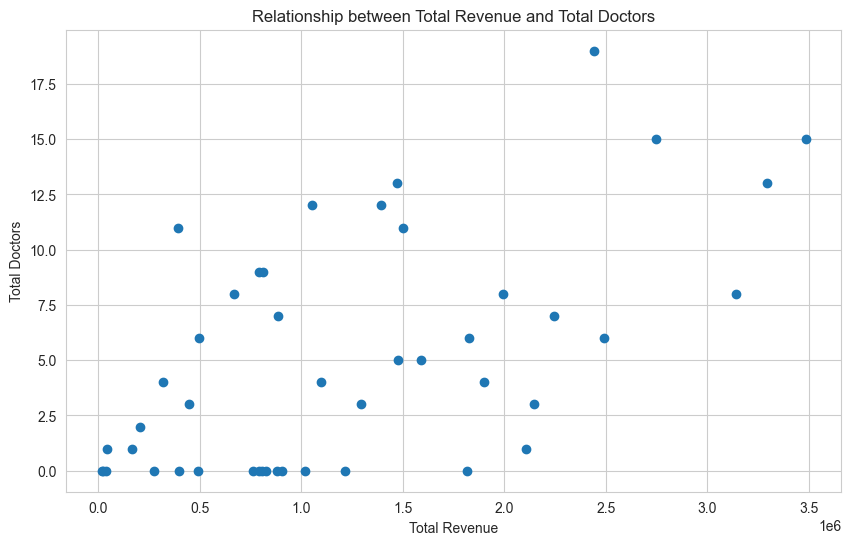

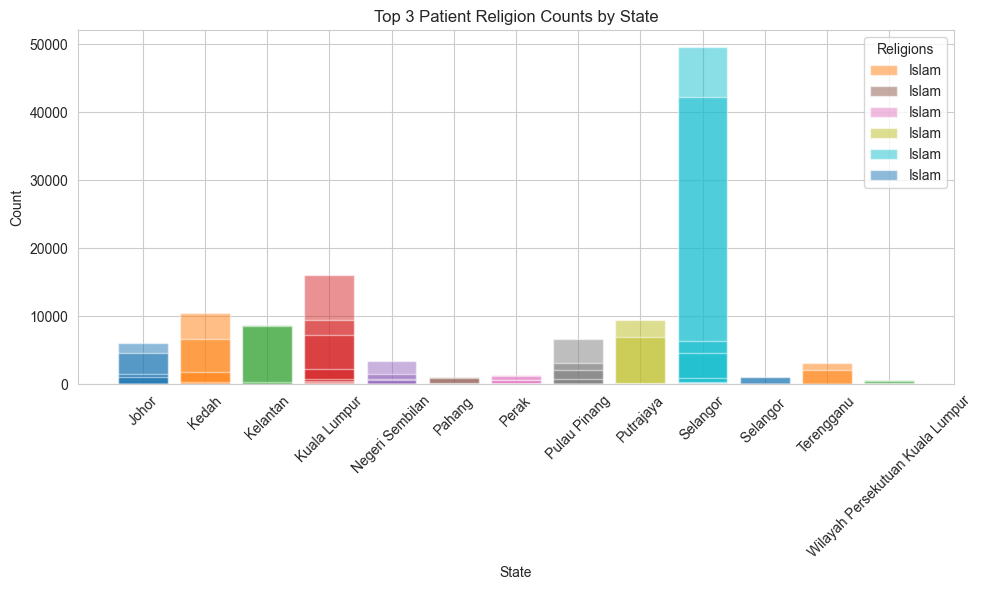

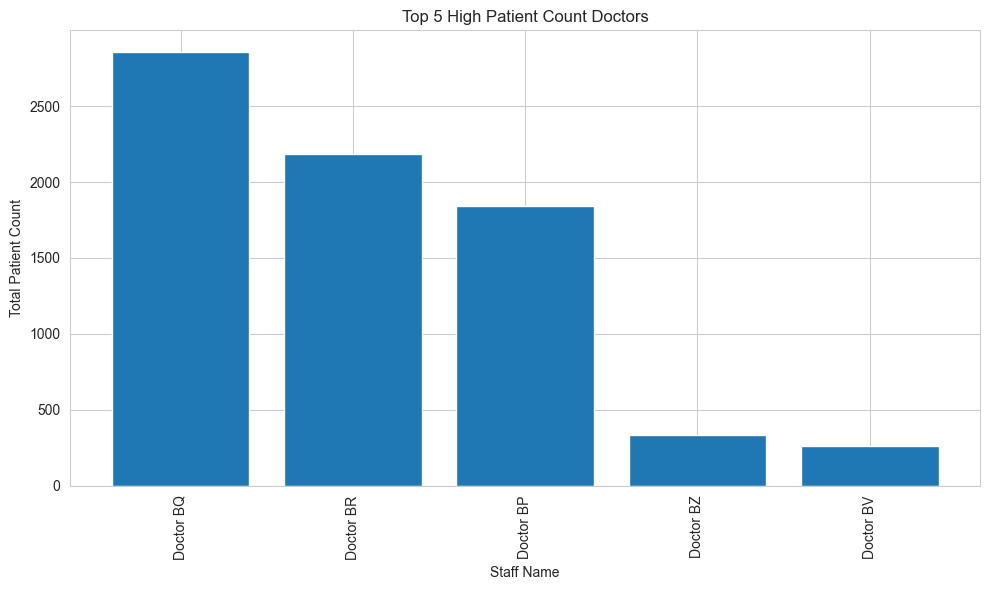

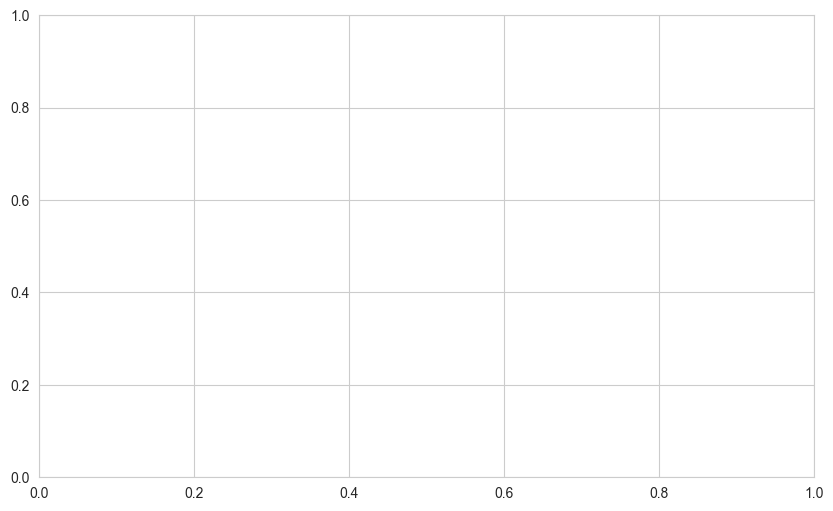

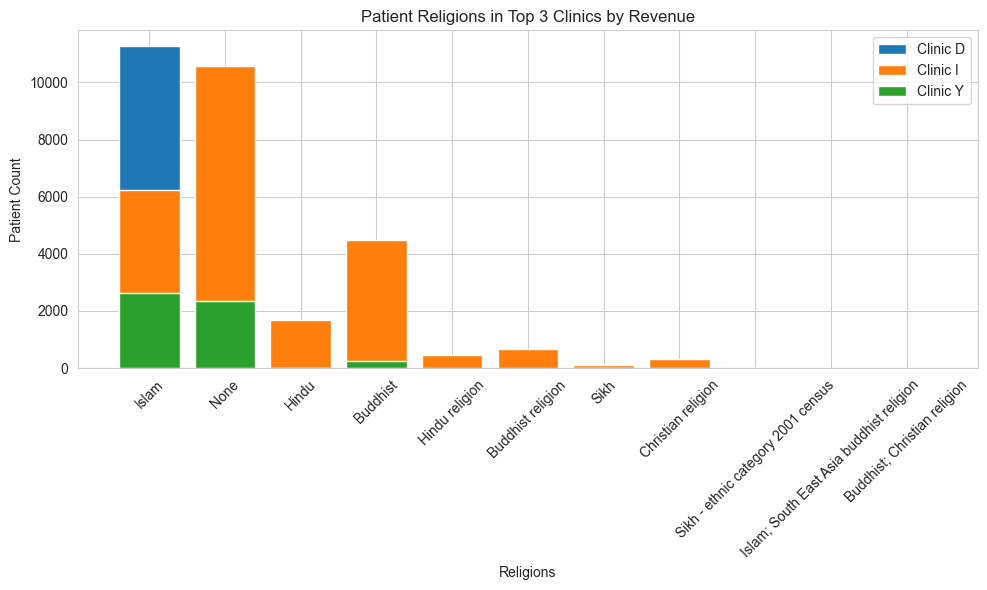

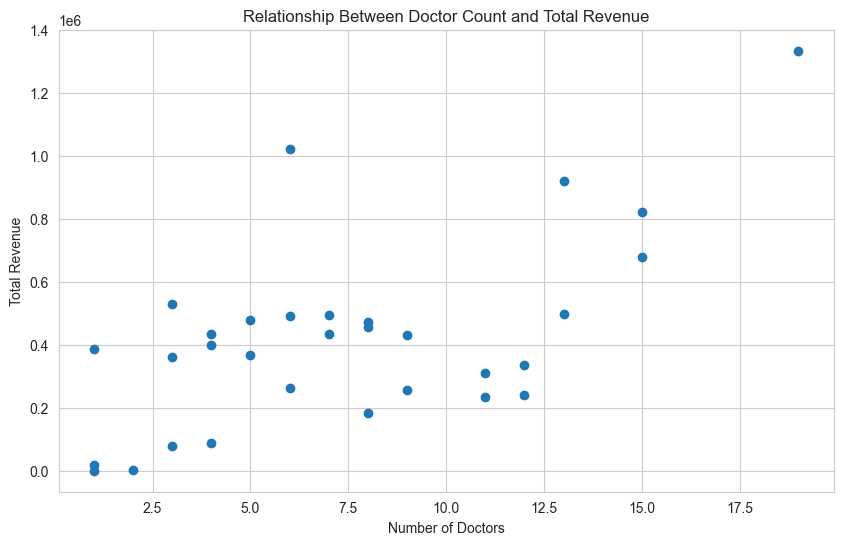

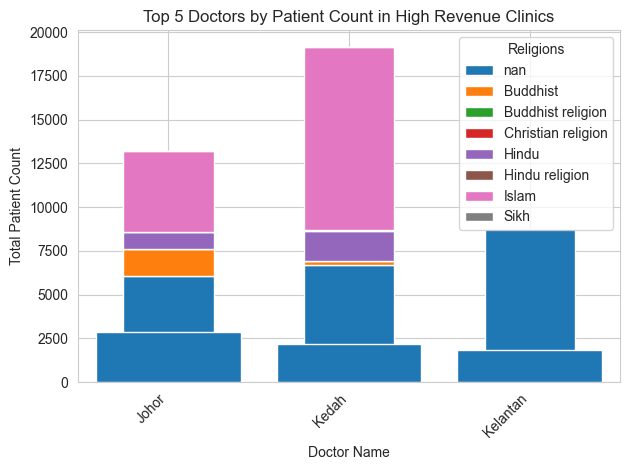

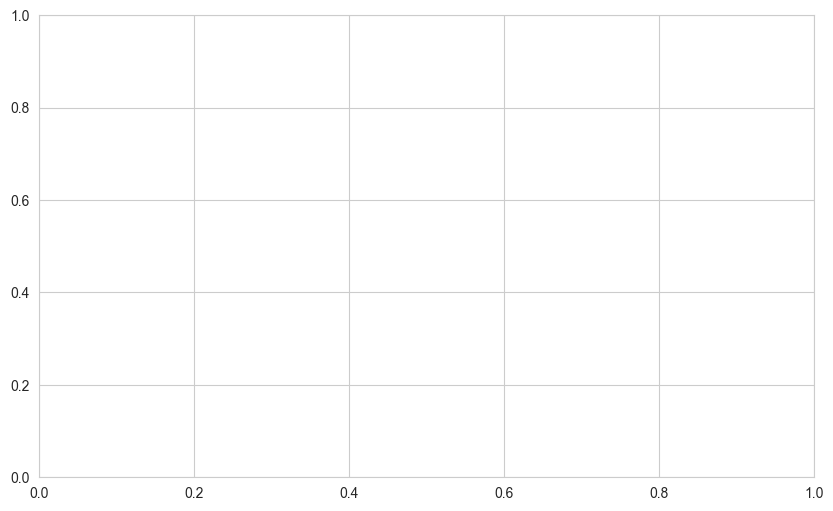

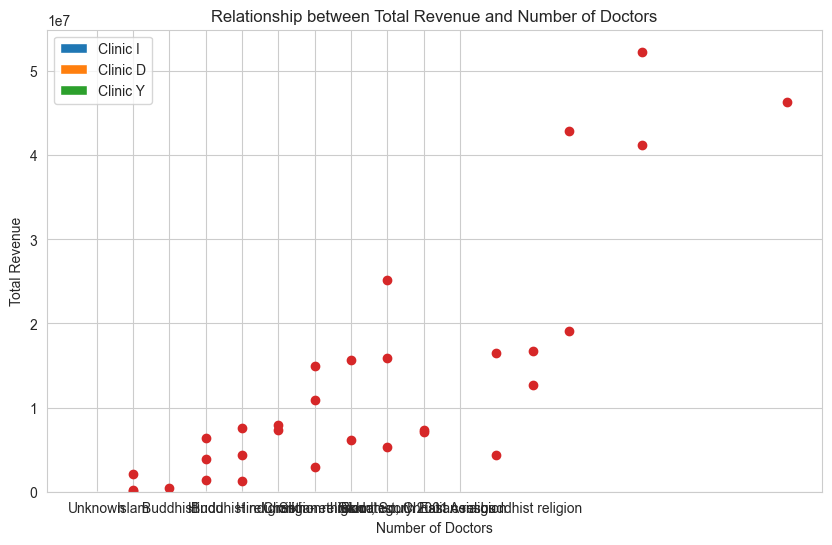

<Figure size 1000x600 with 0 Axes>

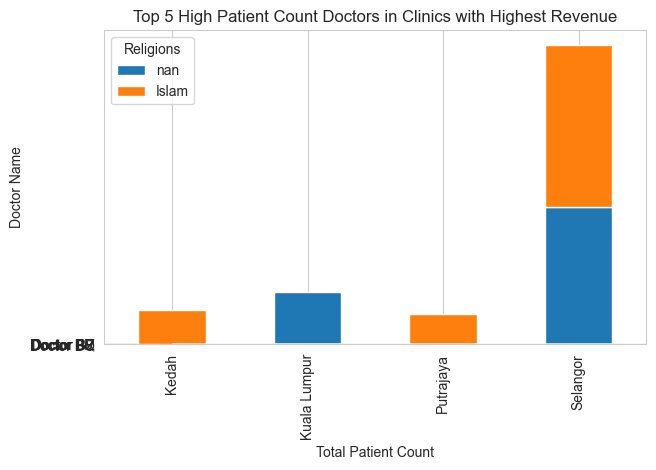

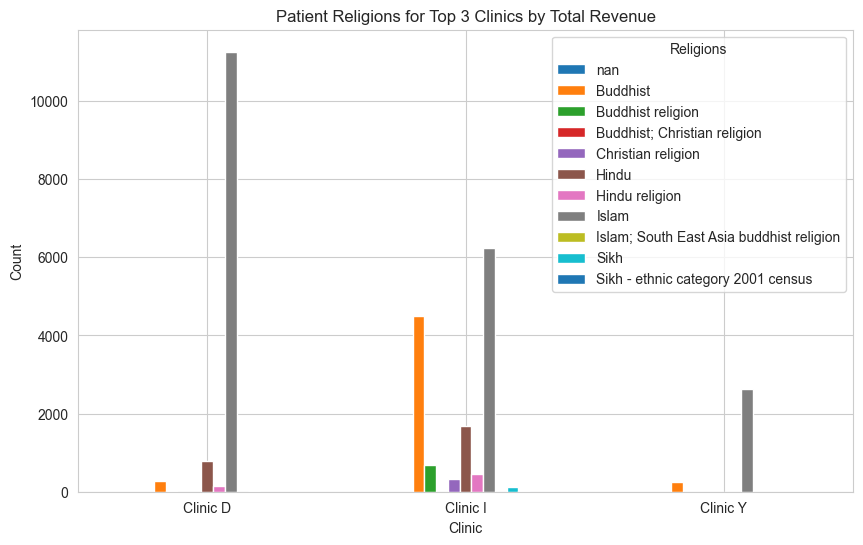

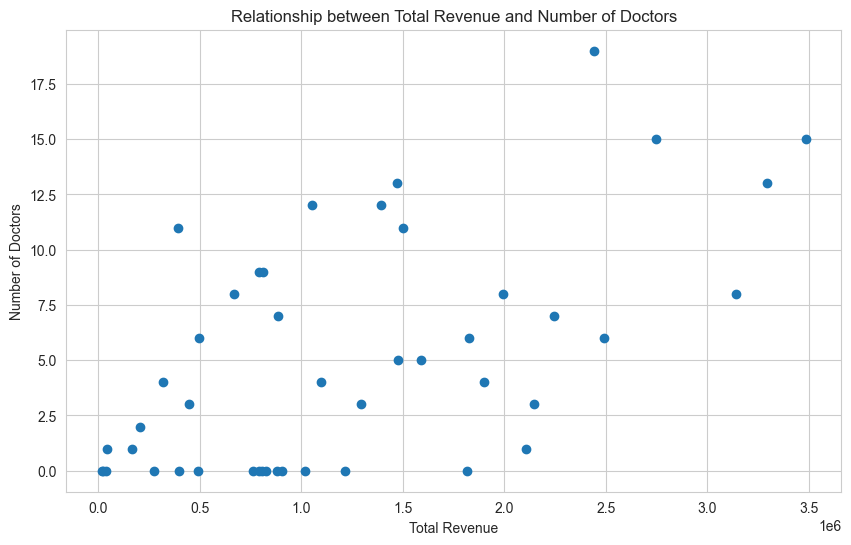

<Figure size 1000x600 with 0 Axes>

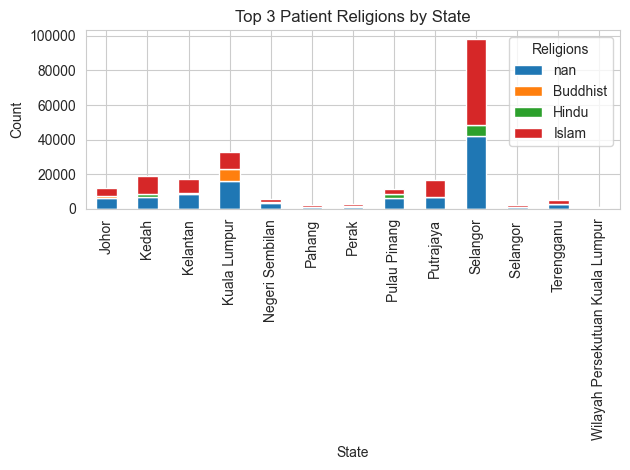

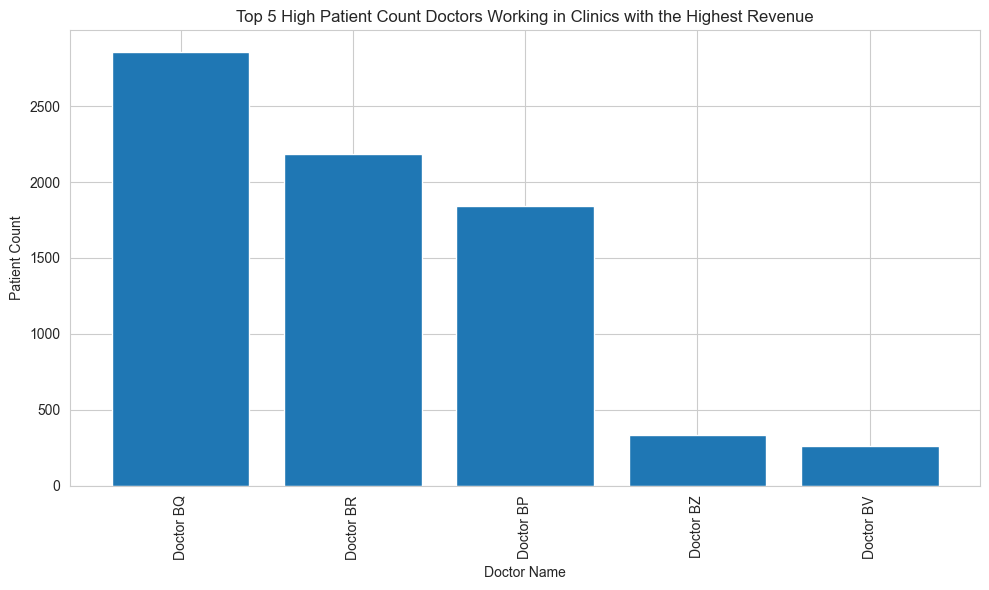

<Figure size 1200x800 with 0 Axes>

In [19]:
# Benchmark Runner - HARD (PLOTS) - Manual Verification Required
# Run this SEPARATELY after Easy/Medium tests

NUM_RUNS = 1
MAX_RETRIES = 2
RESULTS_FILE_HARD = "exports/benchmark_results_hard.csv"

# Load existing hard results
if os.path.exists(RESULTS_FILE_HARD) and os.path.getsize(RESULTS_FILE_HARD) > 0:
    try:
        hard_results_df = pd.read_csv(RESULTS_FILE_HARD)
        hard_results = hard_results_df.to_dict('records')
        print(f"📂 Loaded {len(hard_results)} existing hard results")
    except pd.errors.EmptyDataError:
        hard_results = []
else:
    hard_results = []
    print("📂 Starting fresh hard benchmark")

completed_hard = get_completed_tests(hard_results)
hard_questions = benchmark_questions["hard"]
total_hard = len(models_to_test) * len(hard_questions) * NUM_RUNS

print("\n" + "=" * 70)
print(f"🎨 HARD BENCHMARK (PLOTS) - Manual Verification")
print(f"   {len(models_to_test)} models × {len(hard_questions)} questions × {NUM_RUNS} runs = {total_hard} tests")
print(f"   Already completed: {len(completed_hard)}")
print("=" * 70)
print("⚠️  Charts will be displayed for manual verification")
print("=" * 70)

try:
    for run_num in range(1, NUM_RUNS + 1):
        print(f"\n{'='*70}\n🔄 RUN {run_num}/{NUM_RUNS}\n{'='*70}")
        
        for model_id, model_name in models_to_test:
            print(f"\n🤖 {model_name}")
            
            for idx, q_data in enumerate(hard_questions):
                question = q_data["question"]
                
                if (model_name, "hard", question, run_num) in completed_hard:
                    print(f"  ⏭️ Q{idx+1}: Skipped")
                    continue
                
                print(f"\n  🎨 Q{idx+1}: {question[:50]}...")
                print(f"     Expected: {q_data['answer']}")
                
                try:
                    clear_log()
                    response, elapsed_time = generate_Response(question, q_data["dataframes"], model_id=model_id)
                    response_value = response.value if hasattr(response, 'value') else str(response)
                    
                    
                    generated = extract_Generated_code()
                    sql_query = generated["sql_query"]
                    full_code = generated["full_code"]
                    
                    code_to_validate = full_code if full_code else sql_query
                    is_correct = None
                    if code_to_validate:
                        is_correct = validation_Response(code_to_validate, question, response=response_value)
                    
                    # Display the chart if generated
                    print(f"     Response: {str(response_value)[:100]}...")
                    print(f"     Time: {elapsed_time:.2f}s")
                    print()
                    status = "✅" if str(result["is_correct"]).upper() == "TRUE" else "❌" if result["success"] else "💥"
                    print(f"     Status: {status}")
                    # For plots, we skip auto-validation - mark as needs_review
                    result = {
                        "model": model_name, "difficulty": "hard", "question": question,
                        "expected_answer": q_data["answer"], "run_num": run_num,
                        "response": response_value, "sql_query": generated["sql_query"],
                        "full_code": generated["full_code"], "is_correct": is_correct,
                        "time_seconds": round(elapsed_time, 2), "success": True, "error": None
                    }
                    
                except Exception as e:
                    print(f"     💥 Error: {str(e)[:100]}")
                    result = {
                        "model": model_name, "difficulty": "hard", "question": question,
                        "expected_answer": q_data["answer"], "run_num": run_num,
                        "response": None, "sql_query": None, "full_code": None,
                        "is_correct": False, "time_seconds": None, "success": False, "error": str(e)[:200]
                    }
                
                hard_results.append(result)
                save_results(hard_results, RESULTS_FILE_HARD)
                print(f"     💾 Saved")

except KeyboardInterrupt:
    print("\n⚠️ Interrupted!")
    save_results(hard_results, RESULTS_FILE_HARD)

print(f"\n✅ Hard benchmark complete! Results: {len(hard_results)}")
print(f"📁 Saved to: {RESULTS_FILE_HARD}")
print("\n⚠️  Remember to manually review plots and update 'is_correct' column!")

In [ ]:
# Benchmark Analysis - Run after benchmarks complete
import matplotlib.pyplot as plt

RESULTS_FILE_EM = "exports/benchmark_results_easy_medium.csv"
RESULTS_FILE_HARD = "exports/benchmark_results_hard.csv"

# Load and combine results
dfs = []
if os.path.exists(RESULTS_FILE_EM):
    dfs.append(pd.read_csv(RESULTS_FILE_EM))
    print(f"📂 Loaded Easy/Medium: {len(dfs[-1])} results")
if os.path.exists(RESULTS_FILE_HARD):
    dfs.append(pd.read_csv(RESULTS_FILE_HARD))
    print(f"📂 Loaded Hard: {len(dfs[-1])} results")

if not dfs:
    print("❌ No results found!")
else:
    results_df = pd.concat(dfs, ignore_index=True)
    print(f"📊 Total results: {len(results_df)}")
    
    # Convert is_correct to boolean (handle NEEDS_REVIEW as False for now)
    results_df['correct'] = results_df['is_correct'].astype(str).str.upper() == 'TRUE'
    
    print("\n" + "=" * 70)
    print("📊 BENCHMARK RESULTS ANALYSIS")
    print("=" * 70)
    
    # Accuracy summary
    print("\n📈 Accuracy by Model:")
    accuracy_by_model = results_df.groupby('model')['correct'].mean().sort_values(ascending=False) * 100
    print(accuracy_by_model.round(1).to_string())
    
    print("\n📈 Accuracy by Difficulty:")
    accuracy_by_diff = results_df.groupby('difficulty')['correct'].mean() * 100
    print(accuracy_by_diff.round(1).to_string())
    
    print("\n📈 Accuracy by Model × Difficulty:")
    pivot = results_df.pivot_table(values='correct', index='model', columns='difficulty', aggfunc='mean') * 100
    print(pivot.round(1).to_string())
    
    # Response Time Analysis
    print("\n⏱️ Average Response Time (seconds):")
    time_by_model = results_df.groupby('model')['time_seconds'].mean().sort_values()
    print(time_by_model.round(2).to_string())
    
    # Success Rate
    print("\n✅ Success Rate (no errors):")
    success_by_model = results_df.groupby('model')['success'].mean() * 100
    print(success_by_model.round(1).to_string())
    
    # Check for NEEDS_REVIEW
    needs_review = results_df[results_df['is_correct'].astype(str) == 'NEEDS_REVIEW']
    if len(needs_review) > 0:
        print(f"\n⚠️  {len(needs_review)} hard questions need manual review!")
    
    # Plot results
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    accuracy_by_model.plot(kind='barh', ax=axes[0], color='steelblue')
    axes[0].set_xlabel('Accuracy (%)')
    axes[0].set_title('Accuracy by Model')
    
    time_by_model.plot(kind='barh', ax=axes[1], color='coral')
    axes[1].set_xlabel('Avg Time (s)')
    axes[1].set_title('Response Time by Model')
    
    if len(pivot.columns) > 0:
        pivot.T.plot(kind='bar', ax=axes[2])
        axes[2].set_xlabel('Difficulty')
        axes[2].set_ylabel('Accuracy (%)')
        axes[2].set_title('Model Performance by Difficulty')
        axes[2].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    
    plt.tight_layout()
    plt.savefig('exports/benchmark_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n📁 Analysis saved to exports/benchmark_analysis.png")